The [Street View House Numbers Dataset](https://www.openml.org/d/41081) contains 32-by-32 RGB images centered around a single digit of a house number appearing in Google Street View. Many of the images do contain some distractors at the sides. Your goal is to build a model that recognizes the correct digit. In detail, you need to do the following tasks:
1. Images come from real-world street scenes and include noise, distractors, and varying lighting. This is a multi-class classification problem with 10 output classes. Start with simple models like Logistic Regression using flattened image inputs.
2. Extend to Multi-Layer Perceptrons (MLP) to capture non-linear patterns.
3. Evaluate why these models fail due to lack of spatial feature extraction.
4. Develop Convolutional Neural Networks (CNNs) to capture spatial structure.
5. Apply preprocessing such as normalization and optional data augmentation.
6. Train using cross-entropy loss and evaluate with accuracy and confusion matrix.
7. Compare models and demonstrate performance improvements from simple to advanced architectures.

Load SVHN
→ Preprocessing
→ DataLoader
→ Build CNN
→ Train CNN
→ Validate CNN
→ Test CNN
→ Accuracy + Confusion Matrix
→ Viết nhận xét

In [ ]:
!pip install torch torchvision scikit-learn matplotlib seaborn scipy
!pip install openml

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import openml

# Load dataset từ OpenML

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Install openml if not already installed
# Load SVHN from OpenML (dataset id 41081)
dataset = openml.datasets.get_dataset(41081)
X, y, _, _ = dataset.get_data(target=dataset.default_target_attribute)
X = np.asarray(X, dtype=np.float64)
y = np.asarray(y, dtype=np.int64)

print(f"X shape: {X.shape}")
print(f"y range: {y.min()} – {y.max()}, unique classes: {len(np.unique(y))}")

X shape: (99289, 3072)
y range: 1 – 10, unique classes: 10


# Fix label and reshape picture

In [ ]:
X = np.asarray(X, dtype=np.float32)
y = np.asarray(y, dtype=np.int64)

# Label 10 đại diện cho digit 0
y = np.where(y == 10, 0, y)

# Normalize về [0, 1]
X = X / 255.0

# Reshape theo dạng ảnh H, W, C trước
X = X.reshape(-1, 32, 32, 3)

print("Image shape for visualization:", X.shape)

Image shape for visualization: (99289, 32, 32, 3)


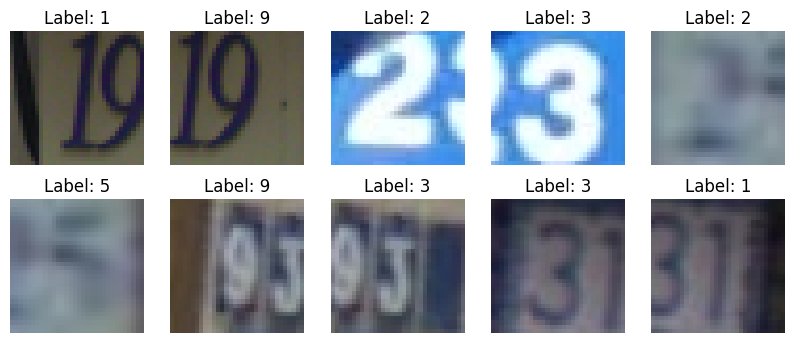

In [ ]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[i])
    plt.title(f"Label: {y[i]}")
    plt.axis("off")

plt.show()

In [ ]:
# Nhưng để đưa vào CNN PyTorch, bạn cần đổi sang:

# N, C, H, W
X_cnn = np.transpose(X, (0, 3, 1, 2))

print("X_cnn shape:", X_cnn.shape)

X_cnn shape: (99289, 3, 32, 32)


# 1. Convert the image to CNN format.

In [ ]:
X_cnn = np.transpose(X, (0, 3, 1, 2)).astype(np.float32)

print("X_cnn shape:", X_cnn.shape)
print("y range:", y.min(), "-", y.max())
print("unique labels:", np.unique(y))
print("X min:", X_cnn.min())
print("X max:", X_cnn.max())

X_cnn shape: (99289, 3, 32, 32)
y range: 0 - 9
unique labels: [0 1 2 3 4 5 6 7 8 9]
X min: 0.0
X max: 1.0


# 2. Split train / validation / test

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X_cnn,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (69502, 3, 32, 32) (69502,)
Validation: (14893, 3, 32, 32) (14893,)
Test: (14894, 3, 32, 32) (14894,)


# 3. Switch to TensorDataset

In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 4. Train CNN

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class SVHNCNN(nn.Module):
    def __init__(self):
        super(SVHNCNN, self).__init__()

        self.features = nn.Sequential(
            # Block 1: input 3 x 32 x 32 -> 32 x 16 x 16
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2: 32 x 16 x 16 -> 64 x 8 x 8
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 3: 64 x 8 x 8 -> 128 x 4 x 4
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = SVHNCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)

Using device: cpu
SVHNCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()

In [ ]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # Reset gradient
        optimizer.zero_grad()

        # Forward
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward
        loss.backward()
        optimizer.step()

        # Loss
        running_loss += loss.item()

        # Accuracy
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [ ]:
def evaluate(model, data_loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            # Forward
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Loss
            running_loss += loss.item()

            # Prediction
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(data_loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc, all_preds, all_labels

# 20 epochs

In [ ]:
num_epochs = 20

train_losses = []
val_losses = []
train_accs = []
val_accs = []

best_val_acc = 0.0

patience = 4          # dừng nếu 4 epochs liên tiếp không cải thiện
min_delta = 0.001     # cải thiện tối thiểu 0.1%
epochs_no_improve = 0

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc, _, _ = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch [{epoch + 1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print("-" * 50)

    # Check improvement
    if val_acc > best_val_acc + min_delta:
        best_val_acc = val_acc
        epochs_no_improve = 0

        torch.save(model.state_dict(), "best_svhn_cnn_20epochs.pth")
        print("Saved best model!")
        print("-" * 50)
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve} epoch(s)")
        print("-" * 50)

    # Early stopping
    if epochs_no_improve >= patience:
        print("Early stopping triggered!")
        print(f"Best Validation Accuracy: {best_val_acc:.4f}")
        break

Epoch [1/20]
Train Loss: 1.3887 | Train Acc: 0.5099
Val Loss:   0.6605 | Val Acc:   0.8215
--------------------------------------------------
Saved best model!
--------------------------------------------------
Epoch [2/20]
Train Loss: 0.8419 | Train Acc: 0.7081
Val Loss:   0.4624 | Val Acc:   0.8760
--------------------------------------------------
Saved best model!
--------------------------------------------------
Epoch [3/20]
Train Loss: 0.7134 | Train Acc: 0.7522
Val Loss:   0.3976 | Val Acc:   0.8901
--------------------------------------------------
Saved best model!
--------------------------------------------------
Epoch [4/20]
Train Loss: 0.6637 | Train Acc: 0.7681
Val Loss:   0.4135 | Val Acc:   0.8906
--------------------------------------------------
No improvement for 1 epoch(s)
--------------------------------------------------
Epoch [5/20]
Train Loss: 0.6241 | Train Acc: 0.7801
Val Loss:   0.3913 | Val Acc:   0.8985
--------------------------------------------------
Sa

In [ ]:
best_model = SVHNCNN().to(device)
best_model.load_state_dict(torch.load("best_svhn_cnn_20epochs.pth"))
best_model.eval()

test_loss, test_acc, y_pred, y_true = evaluate(
    best_model,
    test_loader,
    criterion,
    device
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

Test Loss: 0.3003000595376023
Test Accuracy: 0.919564925473345


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.92      0.92      1004
           1       0.93      0.95      0.94      2844
           2       0.95      0.94      0.94      2210
           3       0.95      0.88      0.92      1707
           4       0.94      0.93      0.94      1497
           5       0.90      0.91      0.91      1390
           6       0.90      0.87      0.88      1156
           7       0.91      0.94      0.93      1142
           8       0.85      0.89      0.87      1006
           9       0.89      0.90      0.90       938

    accuracy                           0.92     14894
   macro avg       0.91      0.91      0.91     14894
weighted avg       0.92      0.92      0.92     14894



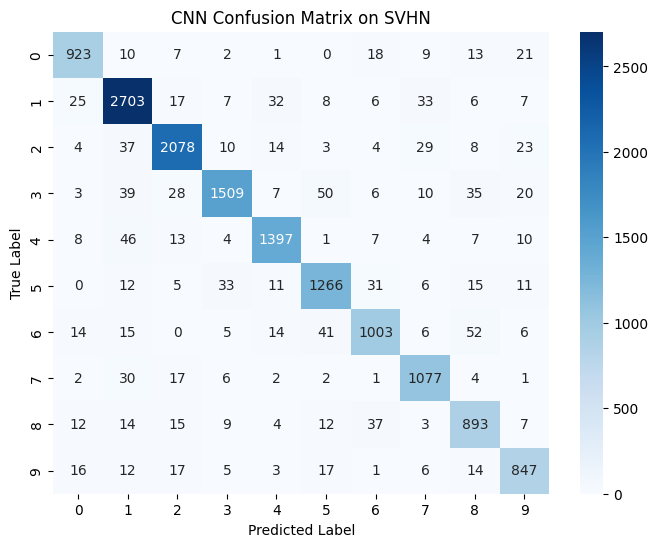

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=list(range(10)),
    yticklabels=list(range(10))
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("CNN Confusion Matrix on SVHN")
plt.show()

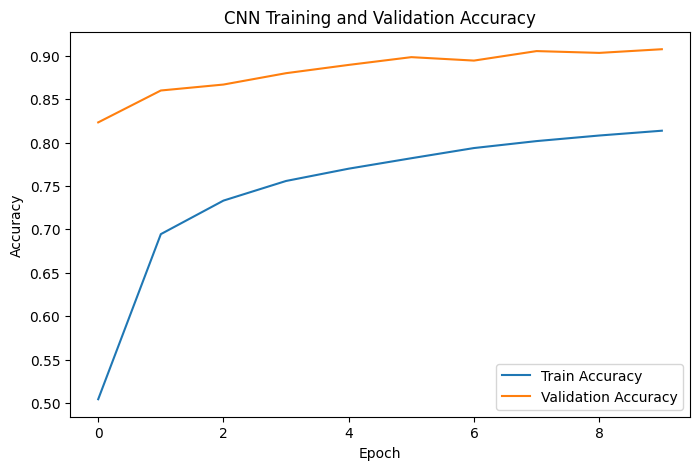

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.legend()
plt.show()

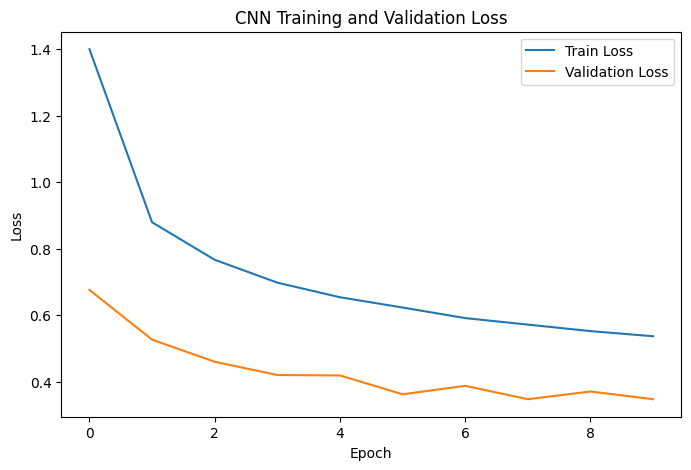

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training and Validation Loss")
plt.legend()
plt.show()

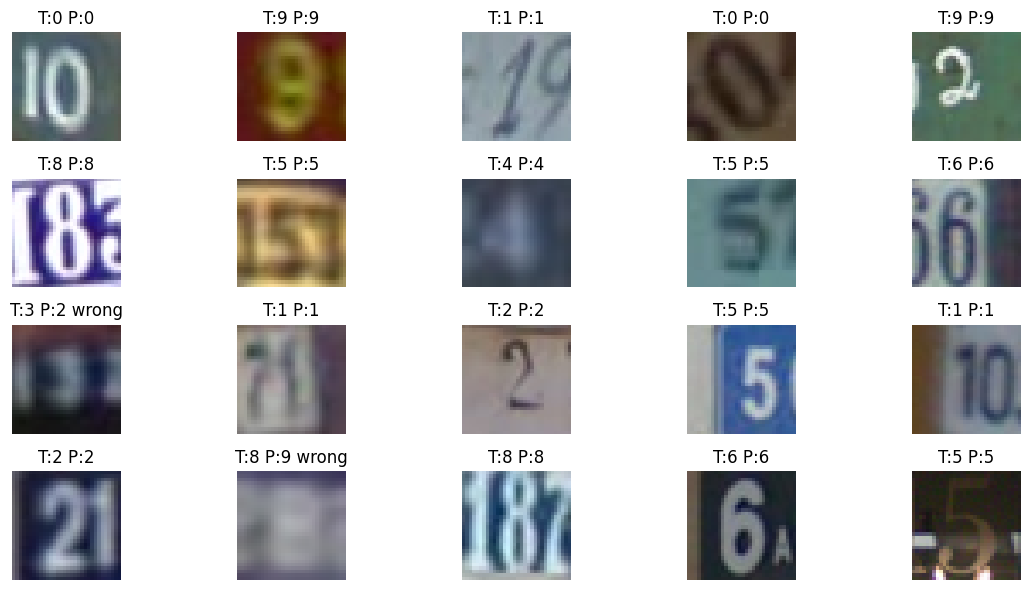

In [ ]:
# 4. Xem vài dự đoán đúng/sai

images, labels = next(iter(test_loader))

images = images.to(device)
labels = labels.to(device)

outputs = best_model(images)
_, predicted = torch.max(outputs, 1)

images = images.cpu()
labels = labels.cpu()
predicted = predicted.cpu()

plt.figure(figsize=(12, 6))

for i in range(20):
    plt.subplot(4, 5, i + 1)

    img = images[i].numpy()
    img = np.transpose(img, (1, 2, 0))

    plt.imshow(img)
    plt.axis("off")

    true_label = labels[i].item()
    pred_label = predicted[i].item()

    if true_label == pred_label:
        plt.title(f"T:{true_label} P:{pred_label}")
    else:
        plt.title(f"T:{true_label} P:{pred_label} wrong")

plt.tight_layout()
plt.show()